In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato, hessian
import os # Import the os module for path manipulation

file_root="/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce"
# 시각화할 5개 파일 리스트
target_files = [
    'bed00_20251214_061656_cam2_b4_p01__core_candidate.png',
    'bed00_20251216_213507_cam2_b2_p01__core_candidate.png',
    'bed00_20251216_213507_cam2_b4_p01__core_candidate.png',
    'bed00_20251220_104615_cam2_b2_p01__core_candidate.png',
    'bed09_20251226_084805_cam2_b4_p01__core_candidate.png'
]

def analyze_and_visualize(root_path, file_names):
    fig, axes = plt.subplots(len(file_names), 4, figsize=(20, 5 * len(file_names)))

    for i, fname in enumerate(file_names):
        full_path = os.path.join(root_path, fname) # Construct the full file path
        img = cv2.imread(full_path)
        if img is None:
            print(f"Warning: Could not read image at {full_path}. Skipping.")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 1. 원본 이미지
        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title(f"Original: {fname.split('_')[4]}")
        axes[i, 0].axis('off')

        # 2. Sato 방향 일관성 (Coherence - 잎의 정렬도)
        # 2차 미분 구조 텐서 대신 Sato의 강도를 방향별로 분석 (보라색 테마)
        sato_img = sato(gray, sigmas=range(1, 5), black_ridges=False)
        axes[i, 1].imshow(sato_img, cmap='Purples')
        axes[i, 1].set_title("Sato Coherence")
        axes[i, 1].axis('off')

        # 3. 색상 기반 능선 (Color Filtered Ridge - 노란색 테마)
        # 연두색/노란색 범위 마스킹 (Hue 20~50)
        lower_yellow = np.array([20, 40, 40])
        upper_yellow = np.array([50, 255, 255])
        color_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
        color_ridge = cv2.bitwise_and(sato_img, sato_img, mask=color_mask)
        axes[i, 2].imshow(color_ridge, cmap='YlOrBr')
        axes[i, 2].set_title("Color-Filtered Ridge")
        axes[i, 2].axis('off')

        # 4. 원형 대칭성/곡률 (Symmetry/Blob - 분홍색 테마)
        # Hessian Determinant를 이용해 둥근 덩어리(Blob) 검출
        h_map = hessian(gray, sigmas=[5])
        axes[i, 3].imshow(np.abs(h_map), cmap='RdPu')
        axes[i, 3].set_title("Symmetry/Blob Detection")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig('manus_analysis_preview.png')
    plt.show()

# 실행 (현재 환경에 파일이 있어야 함)
analyze_and_visualize(file_root, target_files)

Output hidden; open in https://colab.research.google.com to view.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

# Configure matplotlib to use the new font
# fm._rebuild() # This line is causing the error and is no longer needed in newer matplotlib versions
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # Correctly display negative signs

print("Korean font 'NanumGothic' installed and configured for matplotlib.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [10]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [1]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

Arc Concentricity 분석 시작...
  처리 중: bed00_20251214_061656_cam2_b4_p01__core_candidate.png
  처리 중: bed00_20251216_213507_cam2_b2_p01__core_candidate.png
  처리 중: bed00_20251216_213507_cam2_b4_p01__core_candidate.png


KeyboardInterrupt: 

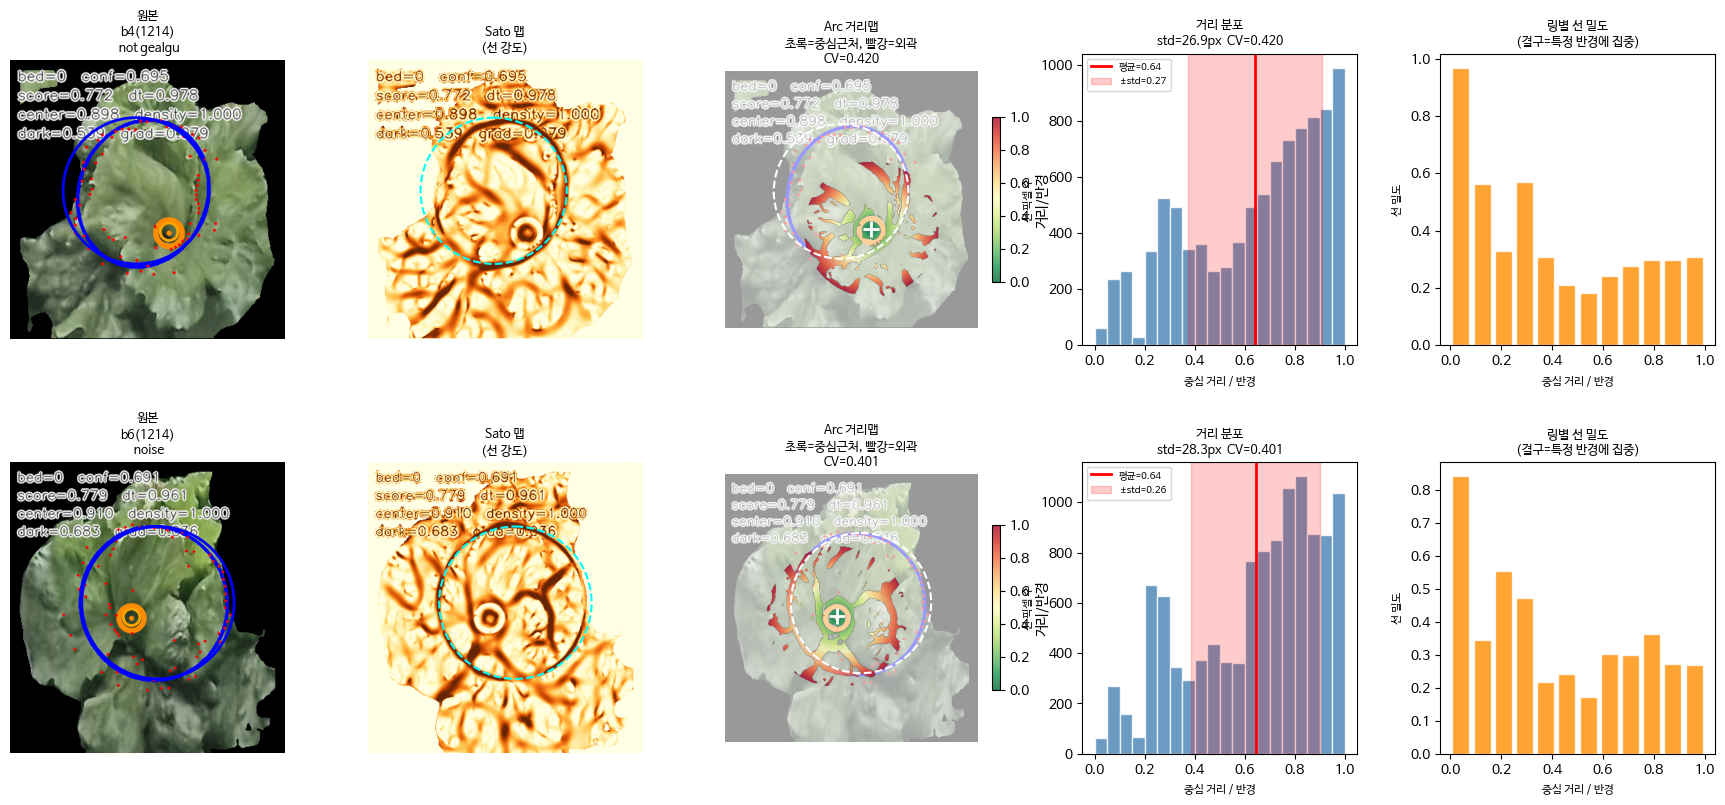

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.filters import sato
from scipy.ndimage import gaussian_filter
from pathlib import Path

# ─────────────────────────────────────────────────────
# 경로 설정 (여기만 수정)
# ─────────────────────────────────────────────────────
IMG_PATHS = [
    Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/bed00_20251214_061656_cam2_b4_p01__core_candidate.png"),
    Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/bed00_20251216_213507_cam2_b2_p01__core_candidate.png"),
    Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/bed00_20251216_213507_cam2_b4_p01__core_candidate.png"),
    Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/bed00_20251219_051713_cam2_b2_p01__core_candidate.png"),
    Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/bed01_20251226_080142_cam2_b4_p01__core_candidate.png"),
]
LABELS = ["b4(1214)\n not gealgu", "b6(1214)\n noise", "b3(1214)\n not gealgu", "b3(1220)\n gealgu 1", "b5(1214)\n gealgu 2"]
OUT_DIR = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc")
OUT_DIR.mkdir(exist_ok=True)

# ─────────────────────────────────────────────────────
# 함수 1: 이미지 로드 및 전처리
# ─────────────────────────────────────────────────────
def load_and_preprocess(img_path):
    # Handle non-ASCII paths for cv2.imread
    try:
        img_np = np.fromfile(str(img_path), np.uint8)
        img = cv2.imdecode(img_np, cv2.IMREAD_COLOR)
    except FileNotFoundError:
        print(f"Error: File not found at {img_path}. Skipping.")
        return None, None, None, None

    if img is None:
        print(f"Error: Could not decode image at {img_path}. Skipping.")
        return None, None, None, None # Return None for all if image cannot be loaded

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 검정 배경 마스크
    mask = (gray > 20).astype(np.uint8) * 255

    # CLAHE 명암 보정
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    enhanced[mask == 0] = 0

    return img_rgb, gray, enhanced, mask

# ─────────────────────────────────────────────────────
# 함수 2: 파란 원(ROI) 추출
# ─────────────────────────────────────────────────────
def get_blue_circle(img_rgb, gray, mask):
    h, w = gray.shape
    # 파란 원 검출: HSV에서 파란색 범위
    hsv = cv2.cvtColor(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
    blue_mask = cv2.inRange(hsv, (100, 80, 80), (130, 255, 255))
    circles = cv2.HoughCircles(
        blue_mask, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
        param1=50, param2=15, minRadius=30, maxRadius=min(h, w)//2
    )
    if circles is not None:
        cx, cy, r = circles[0][0]
        return int(cx), int(cy), int(r)
    # 검출 실패 시 이미지 중심 기반 추정
    ys, xs = np.where(mask > 0)
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    r = int(min(np.std(xs), np.std(ys)) * 1.2)
    return cx, cy, r

# ─────────────────────────────────────────────────────
# 함수 3: 오렌지 원(중심점) 추출
# ─────────────────────────────────────────────────────
def get_orange_center(img_rgb):
    hsv = cv2.cvtColor(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
    orange_mask = cv2.inRange(hsv, (5, 150, 150), (25, 255, 255))
    circles = cv2.HoughCircles(
        orange_mask, cv2.HOUGH_GRADIENT, dp=1, minDist=10,
        param1=50, param2=8, minRadius=5, maxRadius=40
    )
    if circles is not None:
        cx, cy, _ = circles[0][0]
        return int(cx), int(cy)
    # 오렌지 픽셀 무게중심
    ys, xs = np.where(orange_mask > 0)
    if len(xs) > 0:
        return int(np.mean(xs)), int(np.mean(ys))
    return None, None

# ─────────────────────────────────────────────────────
# 함수 4: Sato 맵 계산
# ─────────────────────────────────────────────────────
def compute_sato_map(enhanced, mask):
    img_f = enhanced.astype(np.float64) / 255.0
    result = sato(img_f, sigmas=range(1, 8), black_ridges=True, mode='reflect')
    result[mask == 0] = 0
    return result

# ─────────────────────────────────────────────────────
# 함수 5: Arc Concentricity 계산 (핵심)
# ─────────────────────────────────────────────────────
def compute_arc_concentricity(sato_map, cx, cy, roi_r, threshold_pct=70):
    """
    Sato 맵에서 강한 선 픽셀들을 추출하고,
    각 픽셀에서 중심점(cx, cy)까지의 거리를 계산한다.

    반환:
      dist_map   : 각 픽셀의 중심 거리 (시각화용)
      arc_pixels : 선 픽셀들의 거리 배열
      arc_std    : 거리의 표준편차 (작을수록 동심원 → 결구)
      arc_mean   : 거리의 평균 (결구 진행 시 중심부로 수렴 → 작아짐)
      arc_cv     : 변동계수 = std/mean (정규화된 분산)
      ring_map   : 선 픽셀을 거리 기준으로 색칠한 시각화 맵
    """
    h, w = sato_map.shape

    # ROI 마스크 (파란 원 내부)
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(roi_mask, (cx, cy), roi_r, 255, -1)

    # Sato 맵에서 상위 threshold_pct% 픽셀만 선택 (강한 선만)
    sato_roi = sato_map.copy()
    sato_roi[roi_mask == 0] = 0
    threshold = np.percentile(sato_roi[roi_mask > 0], threshold_pct)
    ridge_mask = (sato_roi > threshold).astype(np.uint8)

    # 각 선 픽셀에서 중심점까지의 거리 계산
    ys, xs = np.where(ridge_mask > 0)
    if len(xs) < 10:
        return None, np.array([]), 0, 0, 0, None

    distances = np.sqrt((xs - cx)**2 + (ys - cy)**2)

    # 지표 계산
    arc_std  = np.std(distances)
    arc_mean = np.mean(distances)
    arc_cv   = arc_std / arc_mean if arc_mean > 0 else 0

    # 시각화용: 선 픽셀을 거리에 따라 색상으로 표현
    # 거리를 0~1로 정규화 → 컬러맵 적용
    dist_map = np.zeros((h, w), dtype=np.float32)
    dist_map[ys, xs] = distances / roi_r  # roi 반경으로 정규화

    # 링 히트맵: 거리 구간별 밀도
    # 0~roi_r 구간을 10개 링으로 나눠 각 링의 선 픽셀 수 계산
    n_rings = 12
    ring_counts = np.zeros(n_rings)
    ring_areas  = np.zeros(n_rings)
    for i in range(n_rings):
        r_inner = roi_r * i / n_rings
        r_outer = roi_r * (i + 1) / n_rings
        in_ring = (distances >= r_inner) & (distances < r_outer)
        ring_counts[i] = np.sum(in_ring)
        # 링 면적(픽셀 수)으로 정규화
        ring_area_px = np.sum(
            (np.sqrt((np.arange(w)[None,:] - cx)**2 +
                     (np.arange(h)[:,None] - cy)**2) >= r_inner) &
            (np.sqrt((np.arange(w)[None,:] - cx)**2 +
                     (np.arange(h)[:,None] - cy)**2) < r_outer) &
            (roi_mask > 0)
        )
        ring_areas[i] = ring_area_px if ring_area_px > 0 else 1

    ring_density = ring_counts / ring_areas  # 링별 선 밀도

    return dist_map, distances, arc_std, arc_mean, arc_cv, ring_density

# ─────────────────────────────────────────────────────
# 메인: 5장 처리 및 시각화
# ─────────────────────────────────────────────────────
print("Arc Concentricity 분석 시작...")

results = []

fig = plt.figure(figsize=(22, len(IMG_PATHS) * 5))
gs = gridspec.GridSpec(len(IMG_PATHS), 5, figure=fig,
                       hspace=0.4, wspace=0.3)

for i, (img_path, label) in enumerate(zip(IMG_PATHS, LABELS)):
    print(f"  처리 중: {img_path.name}")

    img_rgb, gray, enhanced, mask = load_and_preprocess(img_path)
    if img_rgb is None: # Image loading failed, add dummy results and skip plotting for this image
        results.append({
            "label": label,
            "arc_std": np.nan,
            "arc_mean": np.nan,
            "arc_cv": np.nan,
            "n_ridge_px": 0,
            "ring_density": None,
        })
        # Plot an empty row with a "Failed to load" title
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.set_title(f"Failed to load: {label}", fontsize=9, color='red')
        ax1.axis('off')
        for j in range(1, 5):
            ax = fig.add_subplot(gs[i, j])
            ax.axis('off')
        continue # Skip the rest of the processing for this image

    cx_blue, cy_blue, r_blue = get_blue_circle(img_rgb, gray, mask)
    cx_org, cy_org = get_orange_center(img_rgb)

    # 중심점: 오렌지 원 우선, 없으면 파란 원 중심
    if cx_org is not None:
        cx_c, cy_c = cx_org, cy_org
    else:
        cx_c, cy_c = cx_blue, cy_blue

    sato_map = compute_sato_map(enhanced, mask)
    dist_map, distances, arc_std, arc_mean, arc_cv, ring_density = \
        compute_arc_concentricity(sato_map, cx_c, cy_c, r_blue)

    results.append({
        "label": label,
        "arc_std": arc_std,
        "arc_mean": arc_mean,
        "arc_cv": arc_cv,
        "n_ridge_px": len(distances),
        "ring_density": ring_density,
    })

    # ── 열 1: 원본 이미지 + 원 표시
    ax1 = fig.add_subplot(gs[i, 0])
    ax1.imshow(img_rgb)
    circle_blue = plt.Circle((cx_blue, cy_blue), r_blue,
                               color='blue', fill=False, linewidth=2)
    ax1.add_patch(circle_blue)
    if cx_org is not None:
        circle_org = plt.Circle((cx_org, cy_org), 12,
                                  color='orange', fill=False, linewidth=2)
        ax1.add_patch(circle_org)
    ax1.set_title(f"원본\n{label}", fontsize=9)
    ax1.axis('off')

    # ── 열 2: Sato 맵 (비교용)
    ax2 = fig.add_subplot(gs[i, 1])
    ax2.imshow(sato_map, cmap='YlOrBr', vmin=0, vmax=np.percentile(sato_map[sato_map>0], 95) if np.any(sato_map>0) else 1)
    circle2 = plt.Circle((cx_blue, cy_blue), r_blue,
                           color='cyan', fill=False, linewidth=1.5, linestyle='--')
    ax2.add_patch(circle2)
    ax2.set_title("Sato 맵\n(선 강도)", fontsize=9)
    ax2.axis('off')

    # ── 열 3: Arc 거리 맵 (선 픽셀을 거리로 색칠)
    ax3 = fig.add_subplot(gs[i, 2])
    if dist_map is not None:
        # 선 픽셀만 표시 (0인 곳은 투명하게)
        display = np.ma.masked_where(dist_map == 0, dist_map)
        ax3.imshow(img_rgb, alpha=0.4)
        im = ax3.imshow(display, cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.8)
        plt.colorbar(im, ax=ax3, fraction=0.03, label='거리/반경')
        circle3 = plt.Circle((cx_blue, cy_blue), r_blue,
                               color='white', fill=False, linewidth=1.5, linestyle='--')
        ax3.add_patch(circle3)
        # 중심점 표시
        ax3.plot(cx_c, cy_c, 'w+', markersize=12, markeredgewidth=2)
    ax3.set_title(f"Arc 거리맵\n초록=중심근처, 빨강=외곽\nCV={arc_cv:.3f}", fontsize=9)
    ax3.axis('off')

    # ── 열 4: 거리 히스토그램
    ax4 = fig.add_subplot(gs[i, 3])
    if len(distances) > 0:
        ax4.hist(distances / r_blue, bins=20, color='steelblue',
                 edgecolor='white', alpha=0.8, range=(0, 1))
        ax4.axvline(arc_mean / r_blue, color='red', linewidth=2,
                    label=f'평균={arc_mean/r_blue:.2f}')
        ax4.axvspan((arc_mean - arc_std) / r_blue,
                    (arc_mean + arc_std) / r_blue,
                    alpha=0.2, color='red', label=f'±std={arc_std/r_blue:.2f}')
        ax4.set_xlabel('중심 거리 / 반경', fontsize=8)
        ax4.set_ylabel('선 픽셀 수', fontsize=8)
        ax4.legend(fontsize=7)
        ax4.set_title(f"거리 분포\nstd={arc_std:.1f}px  CV={arc_cv:.3f}", fontsize=9)

    # ── 열 5: 링별 선 밀도 (동심원 분석)
    ax5 = fig.add_subplot(gs[i, 4])
    if ring_density is not None:
        n_rings = len(ring_density)
        ring_centers = [(k + 0.5) / n_rings for k in range(n_rings)]
        ax5.bar(ring_centers, ring_density, width=1/n_rings * 0.8,
                color='darkorange', alpha=0.8, edgecolor='white')
        ax5.set_xlabel('중심 거리 / 반경', fontsize=8)
        ax5.set_ylabel('선 밀도', fontsize=8)
        ax5.set_title("링별 선 밀도\n(결구=특정 반경에 집중)", fontsize=9)

fig.suptitle("Arc Concentricity 분석: Sato 선 픽셀의 중심 거리 분포\n"
             "결구 → 특정 반경에 집중(std 작음) | 미결구 → 분산(std 큼)",
             fontsize=13, fontweight='bold', y=1.01)

out_path = OUT_DIR / "arc_concentricity_5images.png"
plt.savefig(out_path, dpi=120, bbox_inches='tight', facecolor='white')
plt.close()
print(f"  저장: {out_path}")

# ─────────────────────────────────────────────────────
# 지표 비교표 출력
# ─────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'이미지':<18} {'arc_std':>10} {'arc_mean':>10} {'arc_cv':>10} {'n_px':>8}")
print("-"*60)
for r in results:
    print(f"{r['label'].replace(chr(10),' '):<18} "
          f"{r['arc_std']:>10.2f} "
          f"{r['arc_mean']:>10.2f} "
          f"{r['arc_cv']:>10.4f} "
          f"{r['n_ridge_px']:>8}")
print("="*60)
print("\n해석 기준:")
print("  arc_cv 작을수록 → 선들이 특정 반경에 집중 → 동심원 패턴 → 결구")
print("  arc_mean 작을수록 → 선들이 중심부에 집중 → 결구 초기 신호")
print(f"\n결과 저장: {OUT_DIR}")

#manus_arc로 한번 가능성 보기 마지막으로..제발

In [3]:

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════
# ★ 경로 설정 (여기만 수정)
# ════════════════════════════════════════════════════════
IMG_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce")      # 이미지 폴더 (_core_candidate.png 파일들)
METRICS_XLSX = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx") # core_strength 라벨 엑셀
OUT_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc")       # 결과 저장 폴더
# ════════════════════════════════════════════════════════

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pip install opencv-python scikit-image numpy pandas matplotlib scipy openpyxl

In [12]:
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ────────────────────────────────────────────────────────
# 함수 1: Sato Tubeness 필터 (엽맥/결 검출)
# ────────────────────────────────────────────────────────
def compute_sato_map(gray):
    img_f = gray.astype(np.float64) / 255.0
    return sato(img_f, sigmas=range(1, 8), black_ridges=True, mode='reflect')


# ────────────────────────────────────────────────────────
# 함수 2: Arc CV 계산 (핵심 지표)
#   arc_cv 작을수록 → 선들이 동심원 배열 → 결구 진행
#   arc_cv 클수록  → 선들이 흩어짐 → 미결구
# ────────────────────────────────────────────────────────
def compute_arc_cv(sato_map, cx, cy, roi_r, threshold_pct=70):
    h, w     = sato_map.shape
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(roi_mask, (int(cx), int(cy)), int(roi_r), 255, -1)

    sato_roi = sato_map.copy()
    sato_roi[roi_mask == 0] = 0
    valid_px = sato_roi[roi_mask > 0]
    if len(valid_px) == 0:
        return np.nan, np.nan, np.nan

    threshold = np.percentile(valid_px, threshold_pct)
    ys, xs    = np.where((sato_roi > threshold) & (roi_mask > 0))
    if len(xs) < 10:
        return np.nan, np.nan, np.nan

    distances = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2)
    arc_cv    = np.std(distances) / np.mean(distances) if np.mean(distances) > 0 else np.nan
    return arc_cv, np.std(distances), np.mean(distances)


# ════════════════════════════════════════════════════════
# 엑셀 로드: 좌표 + 라벨 병합
# ════════════════════════════════════════════════════════
df_metrics = pd.read_excel(METRICS_XLSX)
df_label   = pd.read_excel(METRICS_XLSX)

# image_id 정규화 (확장자 제거해서 통일)
df_metrics['image_id'] = df_metrics['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()
df_label['image_id']   = df_label['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()

df_meta = df_metrics[['image_id', 'center_x', 'center_y', 'axis_major']].copy()
df_meta = df_meta.merge(df_label[['image_id', 'core_strength']], on='image_id', how='left')

print(f"메타 데이터: {len(df_meta)}행 / core_strength 있는 것: {df_meta['core_strength'].notna().sum()}행")


# ════════════════════════════════════════════════════════
# 배치 처리
# ════════════════════════════════════════════════════════
records = []
img_files = sorted(IMG_DIR.glob("*_core_candidate.png"))
print(f"이미지 파일 수: {len(img_files)}")

for i, img_path in enumerate(img_files):
    stem = img_path.stem  # 확장자 제거

    row = df_meta[df_meta['image_id'] == stem]
    if row.empty:
        continue  # 메타 없으면 스킵

    cx       = row['center_x'].values[0]
    cy       = row['center_y'].values[0]
    roi_r    = row['axis_major'].values[0] / 2   # axis_major는 지름 → 반지름으로
    strength = row['core_strength'].values[0]

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"  [SKIP] {img_path.name}")
        continue

    sato_map = compute_sato_map(img)
    arc_cv, arc_std, arc_mean = compute_arc_cv(sato_map, cx, cy, roi_r)

    records.append({
        'image_id':      stem,
        'core_strength': strength,
        'arc_cv':        arc_cv,
        'arc_std':       arc_std,
        'arc_mean':      arc_mean,
        'roi_r':         roi_r,
    })

    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{len(img_files)} 처리 완료...")

df = pd.DataFrame(records)
df.to_csv(OUT_DIR / "arc_cv_results.csv", index=False)
print(f"\n처리 완료: {len(df)}장 / 라벨 매칭: {df['core_strength'].notna().sum()}장")


# ════════════════════════════════════════════════════════
# 분석: 0/1/2 단계 구분 통계
# ════════════════════════════════════════════════════════
df_v = df[df['core_strength'].notna() & df['arc_cv'].notna()].copy()
df_v['core_strength'] = df_v['core_strength'].astype(int)

g = {k: df_v[df_v['core_strength'] == k]['arc_cv'].values for k in [0, 1, 2]}

print("\n" + "=" * 55)
print(f"{'단계':<10} {'n':>5} {'중앙값':>10} {'평균':>10} {'std':>10}")
print("-" * 55)
for k, lbl in [(0, "0(미결구)"), (1, "1(결구중)"), (2, "2(결구완)")]:
    v = g[k]
    if len(v) > 0:
        print(f"{lbl:<12} {len(v):>5} {np.median(v):>10.4f} {np.mean(v):>10.4f} {np.std(v):>10.4f}")
print("=" * 55)

# Kruskal-Wallis (3그룹 동시 비교)
filled = [g[k] for k in [0, 1, 2] if len(g[k]) > 1]
if len(filled) == 3:
    stat, p = stats.kruskal(*filled)
    print(f"\nKruskal-Wallis: H={stat:.3f}, p={p:.4f}  {'★ 유의 (p<0.05)' if p < 0.05 else 'ns (p≥0.05)'}")

# 쌍별 Mann-Whitney
print("\n쌍별 Mann-Whitney U 검정:")
for a, b in [(0, 1), (0, 2), (1, 2)]:
    if len(g[a]) > 1 and len(g[b]) > 1:
        _, p = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
        sig  = "★ p<0.05" if p < 0.05 else ("△ p<0.1" if p < 0.1 else "ns")
        print(f"  {a} vs {b}: p={p:.4f}  {sig}")


# ════════════════════════════════════════════════════════
# 시각화: 상자수염 + 히스토그램
# ════════════════════════════════════════════════════════
colors     = ['#4C72B0', '#DD8452', '#55A868']
labels_str = [f'0 미결구\n(n={len(g[0])})',
              f'1 결구중\n(n={len(g[1])})',
              f'2 결구완\n(n={len(g[2])})']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Arc CV 로 core_strength 0/1/2 구분\n"
             "arc_cv 작을수록 → 선들이 동심원 배열 → 결구 진행",
             fontsize=12, fontweight='bold')

# 상자수염 + 개별 점
ax = axes[0]
bp = ax.boxplot([g[k] for k in [0, 1, 2]],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for xi, k in enumerate([0, 1, 2]):
    jitter = np.random.uniform(-0.15, 0.15, size=len(g[k]))
    ax.scatter(xi + 1 + jitter, g[k], alpha=0.4, s=20, color=colors[xi], zorder=3)

# p값 브라켓
y_max = max(np.max(g[k]) for k in [0, 1, 2] if len(g[k]) > 0)
for idx, (a, b) in enumerate([(0, 1), (0, 2), (1, 2)]):
    if len(g[a]) > 1 and len(g[b]) > 1:
        _, p = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
        sig  = "★" if p < 0.05 else ("△" if p < 0.1 else "ns")
        x1, x2 = a + 1, b + 1
        y = y_max * (1.06 + idx * 0.07)
        ax.plot([x1, x2], [y, y], 'k-', lw=1)
        ax.text((x1 + x2) / 2, y * 1.01, f"p={p:.3f} {sig}",
                ha='center', va='bottom', fontsize=8)

ax.set_xticklabels(labels_str, fontsize=10)
ax.set_ylabel('arc_cv', fontsize=11)
ax.set_title('상자수염 + 개별 데이터', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 히스토그램
ax2 = axes[1]
for k, color, lbl in zip([0, 1, 2], colors, ['0 미결구', '1 결구중', '2 결구완']):
    if len(g[k]) > 0:
        ax2.hist(g[k], bins=15, alpha=0.5, color=color,
                 label=f'{lbl} (n={len(g[k])})',
                 edgecolor='white', density=True)
        ax2.axvline(np.median(g[k]), color=color, lw=2, linestyle='--')
ax2.set_xlabel('arc_cv', fontsize=11)
ax2.set_ylabel('밀도', fontsize=11)
ax2.set_title('분포 히스토그램 (점선=중앙값)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
out_fig = OUT_DIR / "arc_cv_0_1_2_comparison.png"
plt.savefig(out_fig, dpi=130, bbox_inches='tight', facecolor='white')
plt.close()

print(f"\n그래프 저장: {out_fig}")
print(f"CSV 저장:   {OUT_DIR / 'arc_cv_results.csv'}")

메타 데이터: 1088행 / core_strength 있는 것: 1088행
이미지 파일 수: 166
  20/166 처리 완료...
  40/166 처리 완료...
  60/166 처리 완료...
  80/166 처리 완료...
  100/166 처리 완료...
  120/166 처리 완료...
  140/166 처리 완료...
  160/166 처리 완료...

처리 완료: 166장 / 라벨 매칭: 166장

단계             n        중앙값         평균        std
-------------------------------------------------------
0(미결구)          36     0.3869     0.3700     0.0452
1(결구중)          60     0.3588     0.3516     0.0466
2(결구완)          70     0.3524     0.3517     0.0410

Kruskal-Wallis: H=5.063, p=0.0795  ns (p≥0.05)

쌍별 Mann-Whitney U 검정:
  0 vs 1: p=0.0600  △ p<0.1
  0 vs 2: p=0.0304  ★ p<0.05
  1 vs 2: p=0.9944  ns

그래프 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/arc_cv_0_1_2_comparison.png
CSV 저장:   /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5

#1088장에 대해서도 해보기

In [5]:

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════
# ★ 경로 설정 (여기만 수정)
# ════════════════════════════════════════════════════════
IMG_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088")      # 이미지 폴더 (_core_candidate.png 파일들)
METRICS_XLSX = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx") # core_strength 라벨 엑셀
OUT_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc")       # 결과 저장 폴더
# ════════════════════════════════════════════════════════

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
from multiprocessing import Pool
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════
# ★ 경로 설정 (여기만 수정)
# ════════════════════════════════════════════════════════
IMG_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088")      # 이미지 폴더 (_core_candidate.png 파일들)
METRICS_XLSX = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx") # core_strength 라벨 엑셀
OUT_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc")       # 결과 저장 폴더
# ════════════════════════════════════════════════════════

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ────────────────────────────────────────────────────────
# 함수 1: Sato Tubeness 필터 (엽맥/결 검출)
# ────────────────────────────────────────────────────────
def compute_sato_map(gray):
    img_f = gray.astype(np.float64) / 255.0
    return sato(img_f, sigmas=range(1, 8), black_ridges=True, mode='reflect')


# ────────────────────────────────────────────────────────
# 함수 2: Arc CV 계산 (핵심 지표)
#   arc_cv 작을수록 → 선들이 동심원 배열 → 결구 진행
#   arc_cv 클수록  → 선들이 흩어짐 → 미결구
# ────────────────────────────────────────────────────────
def compute_arc_cv(sato_map, cx, cy, roi_r, threshold_pct=70):
    h, w     = sato_map.shape
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(roi_mask, (int(cx), int(cy)), int(roi_r), 255, -1)

    sato_roi = sato_map.copy()
    sato_roi[roi_mask == 0] = 0
    valid_px = sato_roi[roi_mask > 0]
    if len(valid_px) == 0:
        return np.nan, np.nan, np.nan

    threshold = np.percentile(valid_px, threshold_pct)
    ys, xs    = np.where((sato_roi > threshold) & (roi_mask > 0))
    if len(xs) < 10:
        return np.nan, np.nan, np.nan

    distances = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2)
    arc_cv    = np.std(distances) / np.mean(distances) if np.mean(distances) > 0 else np.nan
    return arc_cv, np.std(distances), np.mean(distances)


# ────────────────────────────────────────────────────────
# 함수 3: 단일 이미지 처리 (병렬 처리를 위함)
# ────────────────────────────────────────────────────────
def process_single_image(img_path_and_meta):
    img_path, df_meta_broadcast = img_path_and_meta # df_meta is passed as a broadcast variable
    stem = img_path.stem

    row = df_meta_broadcast[df_meta_broadcast['image_id'] == stem]
    if row.empty:
        return None  # Skip if no metadata

    cx       = row['center_x'].values[0]
    cy       = row['center_y'].values[0]
    roi_r    = row['axis_major'].values[0] / 2   # axis_major는 지름 → 반지름으로
    strength = row['core_strength'].values[0]

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"  [SKIP] {img_path.name}")
        return None

    sato_map = compute_sato_map(img)
    arc_cv, arc_std, arc_mean = compute_arc_cv(sato_map, cx, cy, roi_r)

    return {
        'image_id':      stem,
        'core_strength': strength,
        'arc_cv':        arc_cv,
        'arc_std':       arc_std,
        'arc_mean':      arc_mean,
        'roi_r':         roi_r,
    }


# ════════════════════════════════════════════════════════
# 엑셀 로드: 좌표 + 라벨 병합
# ════════════════════════════════════════════════════════
df_metrics = pd.read_excel(METRICS_XLSX)
df_label   = pd.read_excel(METRICS_XLSX)

# image_id 정규화 (확장자 제거해서 통일)
df_metrics['image_id'] = df_metrics['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()
df_label['image_id']   = df_label['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()

df_meta = df_metrics[['image_id', 'center_x', 'center_y', 'axis_major']].copy()
df_meta = df_meta.merge(df_label[['image_id', 'core_strength']], on='image_id', how='left')

print(f"메타 데이터: {len(df_meta)}행 / core_strength 있는 것: {df_meta['core_strength'].notna().sum()}행")


# ════════════════════════════════════════════════════════
# 배치 처리 (병렬 실행)
# ════════════════════════════════════════════════════════
img_files = sorted(IMG_DIR.glob("*_core_candidate.png"))
print(f"이미지 파일 수: {len(img_files)}")

# Prepare arguments for multiprocessing, broadcasting df_meta to each process
args_for_pool = [(img_path, df_meta) for img_path in img_files]

# Use multiprocessing Pool
num_processes = 4  # User requested 4 parallel processes
records = []
with Pool(num_processes) as pool:
    # Use starmap to pass multiple arguments to the worker function
    for i, res in enumerate(pool.imap_unordered(process_single_image, args_for_pool)):
        if res is not None:
            records.append(res)
        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{len(img_files)} 처리 완료...")

df = pd.DataFrame(records)
df.to_csv(OUT_DIR / "arc_cv_results.csv", index=False)
print(f"\n처리 완료: {len(df)}장 / 라벨 매칭: {df['core_strength'].notna().sum()}장")


# ════════════════════════════════════════════════════════
# 분석: 0/1/2 단계 구분 통계
# ════════════════════════════════════════════════════════
df_v = df[df['core_strength'].notna() & df['arc_cv'].notna()].copy()
df_v['core_strength'] = df_v['core_strength'].astype(int)

g = {k: df_v[df_v['core_strength'] == k]['arc_cv'].values for k in [0, 1, 2]}

print("\n" + "=" * 55)
print(f"{'단계':<10} {'n':>5} {'중앙값':>10} {'평균':>10} {'std':>10}")
print("-" * 55)
for k, lbl in [(0, "0(미결구)"), (1, "1(결구중)"), (2, "2(결구완)")]:
    v = g[k]
    if len(v) > 0:
        print(f"{lbl:<12} {len(v):>5} {np.median(v):>10.4f} {np.mean(v):>10.4f} {np.std(v):>10.4f}")
print("=" * 55)

# Kruskal-Wallis (3그룹 동시 비교)
filled = [g[k] for k in [0, 1, 2] if len(g[k]) > 1]
if len(filled) == 3:
    stat, p = stats.kruskal(*filled)
    print(f"\nKruskal-Wallis: H={stat:.3f}, p={p:.4f}  {'★ 유의 (p<0.05)' if p < 0.05 else 'ns (p≥0.05)'}")

# 쌍별 Mann-Whitney
print("\n쌍별 Mann-Whitney U 검정:")
for a, b in [(0, 1), (0, 2), (1, 2)]:
    if len(g[a]) > 1 and len(g[b]) > 1:
        _, p = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
        sig  = "★ p<0.05" if p < 0.05 else ("△ p<0.1" if p < 0.1 else "ns")
        print(f"  {a} vs {b}: p={p:.4f}  {sig}")


# ════════════════════════════════════════════════════════
# 시각화: 상자수염 + 히스토그램
# ════════════════════════════════════════════════════════
colors     = ['#4C72B0', '#DD8452', '#55A868']
labels_str = [f'0 미결구\n(n={len(g[0])})',
              f'1 결구중\n(n={len(g[1])})',
              f'2 결구완\n(n={len(g[2])})']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Arc CV 로 core_strength 0/1/2 구분\n"
             "arc_cv 작을수록 → 선들이 동심원 배열 → 결구 진행",
             fontsize=12, fontweight='bold')

# 상자수염 + 개별 점
ax = axes[0]
bp = ax.boxplot([g[k] for k in [0, 1, 2]],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for xi, k in enumerate([0, 1, 2]):
    jitter = np.random.uniform(-0.15, 0.15, size=len(g[k]))
    ax.scatter(xi + 1 + jitter, g[k], alpha=0.4, s=20, color=colors[xi], zorder=3)

# p값 브라켓
y_max = max(np.max(g[k]) for k in [0, 1, 2] if len(g[k]) > 0)
for idx, (a, b) in enumerate([(0, 1), (0, 2), (1, 2)]):
    if len(g[a]) > 1 and len(g[b]) > 1:
        _, p = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
        sig  = "★" if p < 0.05 else ("△" if p < 0.1 else "ns")
        x1, x2 = a + 1, b + 1
        y = y_max * (1.06 + idx * 0.07)
        ax.plot([x1, x2], [y, y], 'k-', lw=1)
        ax.text((x1 + x2) / 2, y * 1.01, f"p={p:.3f} {sig}",
                ha='center', va='bottom', fontsize=8)

ax.set_xticklabels(labels_str, fontsize=10)
ax.set_ylabel('arc_cv', fontsize=11)
ax.set_title('상자수염 + 개별 데이터', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 히스토그램
ax2 = axes[1]
for k, color, lbl in zip([0, 1, 2], colors, ['0 미결구', '1 결구중', '2 결구완']):
    if len(g[k]) > 0:
        ax2.hist(g[k], bins=15, alpha=0.5, color=color,
                 label=f'{lbl} (n={len(g[k])})',
                 edgecolor='white', density=True)
        ax2.axvline(np.median(g[k]), color=color, lw=2, linestyle='--')
ax2.set_xlabel('arc_cv', fontsize=11)
ax2.set_ylabel('밀도', fontsize=11)
ax2.set_title('분포 히스토그램 (점선=중앙값)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
out_fig = OUT_DIR / "arc_cv_0_1_2_comparison_1088.png"
plt.savefig(out_fig, dpi=130, bbox_inches='tight', facecolor='white')
plt.close()

print(f"\n그래프 저장: {out_fig}")
print(f"CSV 저장:   {OUT_DIR / 'arc_cv_results_1088.csv'}")

메타 데이터: 1088행 / core_strength 있는 것: 1088행
이미지 파일 수: 1088
  20/1088 처리 완료...
  40/1088 처리 완료...
  60/1088 처리 완료...
  80/1088 처리 완료...
  100/1088 처리 완료...
  120/1088 처리 완료...
  140/1088 처리 완료...
  160/1088 처리 완료...
  180/1088 처리 완료...
  200/1088 처리 완료...
  220/1088 처리 완료...
  240/1088 처리 완료...
  260/1088 처리 완료...
  280/1088 처리 완료...
  300/1088 처리 완료...
  320/1088 처리 완료...
  340/1088 처리 완료...
  360/1088 처리 완료...
  380/1088 처리 완료...
  400/1088 처리 완료...
  420/1088 처리 완료...
  440/1088 처리 완료...
  460/1088 처리 완료...
  480/1088 처리 완료...
  500/1088 처리 완료...
  520/1088 처리 완료...
  540/1088 처리 완료...
  560/1088 처리 완료...
  580/1088 처리 완료...
  600/1088 처리 완료...
  620/1088 처리 완료...
  640/1088 처리 완료...
  660/1088 처리 완료...
  680/1088 처리 완료...
  700/1088 처리 완료...
  720/1088 처리 완료...
  740/1088 처리 완료...
  760/1088 처리 완료...
  780/1088 처리 완료...
  800/1088 처리 완료...
  820/1088 처리 완료...
  840/1088 처리 완료...
  860/1088 처리 완료...
  880/1088 처리 완료...
  900/1088 처리 완료...
  920/1088 처리 완료...
  940/1088 처리 완료...
  960/1


처리 완료: 1088장 / 라벨 매칭: 1088장

단계             n        중앙값         평균        std
-------------------------------------------------------
0(미결구)         474     0.3675     0.3649     0.0434
1(결구중)         492     0.3605     0.3579     0.0443
2(결구완)         122     0.3631     0.3580     0.0408

Kruskal-Wallis: H=7.651, p=0.0218  ★ 유의 (p<0.05)

쌍별 Mann-Whitney U 검정:
  0 vs 1: p=0.0102  ★ p<0.05
  0 vs 2: p=0.0711  △ p<0.1
  1 vs 2: p=0.9443  ns



그래프 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/arc_cv_0_1_2_comparison_1088.png
CSV 저장:   /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/arc_cv_results_1088.csv


#개선된 방식으로 지표 다시뽑기

In [8]:
"""
Sato 선 분포 기반 지표 배치 처리 v1
- 영역: 파란 원(axis_major) 내부로 제한
- 중심: 오렌지 원(center_x, center_y) 기준
- 측정 대상: Sato Tubeness 선 픽셀 (mask/threshold 아님)
- core_strength 0/1/2 단계 구분 가능 여부 확인

[필요 패키지]
pip install opencv-python scikit-image numpy pandas matplotlib scipy openpyxl
"""

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════
# ★ 경로 설정 (여기만 수정)
# ════════════════════════════════════════════════════════
IMG_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088")      # 이미지 폴더 (_core_candidate.png 파일들)
METRICS_XLSX = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx") # core_strength 라벨 엑셀
LABEL_XLSX= Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx") # core_strength 라벨 엑셀
OUT_DIR    = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc")       # 결과 저장 폴더
# ════════════════════════════════════════════════════════


OUT_DIR.mkdir(parents=True, exist_ok=True)


# ────────────────────────────────────────────────────────
# 함수: Sato 선 픽셀 기반 지표 계산
#
# [영역] 파란 원(roi_r) 내부
# [중심] 오렌지 원(cx, cy)
# [대상] Sato Tubeness 상위 30% 픽셀 (선 픽셀)
#
# 계산 지표:
#   ridge_density    : 파란 원 내 선 픽셀 비율 (선이 얼마나 빽빽한가)
#   ridge_mean_r     : 선 픽셀들의 평균 반경 (정규화: /roi_r)
#   ridge_std_r      : 선 픽셀들의 반경 표준편차 (정규화: /roi_r)
#   arc_cv           : ridge_std_r / ridge_mean_r (동심원 정도)
#   inner_ratio_30   : 반경 30% 이내에 있는 선 픽셀 비율 (코어 집중도)
#   inner_ratio_50   : 반경 50% 이내에 있는 선 픽셀 비율
#   angular_cv       : 8방향 각도 구간별 선 픽셀 수의 CV (방사 대칭성)
#   ridge_circularity: 선 픽셀들이 얼마나 원형으로 분포하는가
#                      = 1 - (선 픽셀 반경 std / 선 픽셀 반경 mean)
#                      결구 진행 → 1에 가까움
# ────────────────────────────────────────────────────────
def compute_ridge_metrics(gray, cx, cy, roi_r, threshold_pct=70):
    """
    gray    : 그레이스케일 이미지 (밝기 보정 완료본)
    cx, cy  : 오렌지 원 중심 좌표
    roi_r   : 파란 원 반지름
    """
    h, w = gray.shape

    # 1. Sato Tubeness 계산
    img_f    = gray.astype(np.float64) / 255.0
    sato_map = sato(img_f, sigmas=range(1, 8), black_ridges=True, mode='reflect')

    # 2. 파란 원 내부 마스크
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(roi_mask, (int(cx), int(cy)), int(roi_r), 255, -1)

    # 3. 파란 원 내부 Sato 값만 추출
    sato_roi  = sato_map.copy()
    sato_roi[roi_mask == 0] = 0
    valid_all = sato_roi[roi_mask > 0]

    if len(valid_all) == 0:
        return {k: np.nan for k in ['ridge_density', 'ridge_mean_r', 'ridge_std_r',
                                     'arc_cv', 'inner_ratio_30', 'inner_ratio_50',
                                     'angular_cv', 'ridge_circularity']}

    # 4. 상위 threshold_pct% → 선 픽셀 선택
    thr      = np.percentile(valid_all, threshold_pct)
    ys, xs   = np.where((sato_roi > thr) & (roi_mask > 0))
    n_ridge  = len(xs)
    n_total  = np.sum(roi_mask > 0)

    if n_ridge < 10:
        return {k: np.nan for k in ['ridge_density', 'ridge_mean_r', 'ridge_std_r',
                                     'arc_cv', 'inner_ratio_30', 'inner_ratio_50',
                                     'angular_cv', 'ridge_circularity']}

    # 5. 각 선 픽셀의 중심(오렌지 원)까지 반경 계산
    radii = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2)

    # 6. 지표 계산
    ridge_density = n_ridge / n_total                          # 선 밀도
    ridge_mean_r  = np.mean(radii) / roi_r                    # 정규화 평균 반경
    ridge_std_r   = np.std(radii) / roi_r                     # 정규화 반경 표준편차
    arc_cv        = ridge_std_r / ridge_mean_r if ridge_mean_r > 0 else np.nan  # 동심원 정도

    inner_ratio_30 = np.sum(radii < 0.3 * roi_r) / n_ridge   # 코어 30% 이내 집중도
    inner_ratio_50 = np.sum(radii < 0.5 * roi_r) / n_ridge   # 코어 50% 이내 집중도

    # 8방향 각도 구간별 선 픽셀 수 → CV (방사 대칭성)
    angles     = np.arctan2(ys - cy, xs - cx)                 # -π ~ π
    bins       = np.linspace(-np.pi, np.pi, 9)                # 8구간
    counts, _  = np.histogram(angles, bins=bins)
    angular_cv = np.std(counts) / np.mean(counts) if np.mean(counts) > 0 else np.nan

    # 원형 분포 정도: 1에 가까울수록 동심원 패턴 (결구)
    ridge_circularity = 1.0 - (np.std(radii) / np.mean(radii)) if np.mean(radii) > 0 else np.nan

    return {
        'ridge_density':     round(ridge_density, 4),
        'ridge_mean_r':      round(ridge_mean_r, 4),
        'ridge_std_r':       round(ridge_std_r, 4),
        'arc_cv':            round(arc_cv, 4),
        'inner_ratio_30':    round(inner_ratio_30, 4),
        'inner_ratio_50':    round(inner_ratio_50, 4),
        'angular_cv':        round(angular_cv, 4),
        'ridge_circularity': round(ridge_circularity, 4),
    }


# ════════════════════════════════════════════════════════
# 엑셀 로드 및 병합
# ════════════════════════════════════════════════════════
df_metrics = pd.read_excel(METRICS_XLSX)
df_label   = pd.read_excel(LABEL_XLSX)

df_metrics['image_id'] = df_metrics['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()
df_label['image_id']   = df_label['image_id'].astype(str).str.replace('.png', '', regex=False).str.strip()

df_meta = df_metrics[['image_id', 'center_x', 'center_y', 'axis_major']].copy()
df_meta = df_meta.merge(df_label[['image_id', 'core_strength']], on='image_id', how='left')

print(f"메타 데이터: {len(df_meta)}행 / core_strength 있는 것: {df_meta['core_strength'].notna().sum()}행")


# ════════════════════════════════════════════════════════
# 배치 처리
# ════════════════════════════════════════════════════════
img_files = sorted(IMG_DIR.glob("*_core_candidate.png"))
print(f"이미지 파일 수: {len(img_files)}")

records = []
for i, img_path in enumerate(img_files):
    stem = img_path.stem

    row = df_meta[df_meta['image_id'] == stem]
    if row.empty:
        continue

    cx       = float(row['center_x'].values[0])
    cy       = float(row['center_y'].values[0])
    roi_r    = float(row['axis_major'].values[0]) / 2   # axis_major가 지름이면 /2, 반지름이면 제거
    strength = row['core_strength'].values[0]

    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"  [SKIP] {img_path.name}")
        continue

    metrics = compute_ridge_metrics(gray, cx, cy, roi_r)
    metrics['image_id']      = stem
    metrics['core_strength'] = strength
    records.append(metrics)

    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{len(img_files)} 처리 완료...")

df = pd.DataFrame(records)
col_order = ['image_id', 'core_strength',
             'arc_cv', 'ridge_circularity',
             'inner_ratio_30', 'inner_ratio_50',
             'angular_cv', 'ridge_density',
             'ridge_mean_r', 'ridge_std_r']
df = df[col_order]
df.to_csv(OUT_DIR / "ridge_metrics_results.csv", index=False)
print(f"\n처리 완료: {len(df)}장 / 라벨 매칭: {df['core_strength'].notna().sum()}장")


# ════════════════════════════════════════════════════════
# 분석: 각 지표별 0/1/2 단계 Kruskal-Wallis
# ════════════════════════════════════════════════════════
df_v = df[df['core_strength'].notna()].copy()
df_v['core_strength'] = df_v['core_strength'].astype(int)

metric_cols = ['arc_cv', 'ridge_circularity', 'inner_ratio_30', 'inner_ratio_50',
               'angular_cv', 'ridge_density', 'ridge_mean_r', 'ridge_std_r']

print("\n" + "=" * 70)
print(f"{'지표':<22} {'H':>8} {'p값':>10} {'0 중앙값':>10} {'1 중앙값':>10} {'2 중앙값':>10}")
print("-" * 70)

results = []
for col in metric_cols:
    sub = df_v[df_v[col].notna()]
    g   = {k: sub[sub['core_strength'] == k][col].values for k in [0, 1, 2]}
    filled = [g[k] for k in [0, 1, 2] if len(g[k]) > 1]
    if len(filled) < 2:
        continue
    stat, p = stats.kruskal(*filled)
    sig = "★" if p < 0.05 else ("△" if p < 0.1 else "  ")
    m0 = np.median(g[0]) if len(g[0]) > 0 else np.nan
    m1 = np.median(g[1]) if len(g[1]) > 0 else np.nan
    m2 = np.median(g[2]) if len(g[2]) > 0 else np.nan
    print(f"{col:<22} {stat:>8.3f} {p:>10.4f} {sig}  {m0:>8.4f}  {m1:>8.4f}  {m2:>8.4f}")
    results.append({'metric': col, 'H': stat, 'p': p,
                    'med_0': m0, 'med_1': m1, 'med_2': m2})

print("=" * 70)
print("★ p<0.05  △ p<0.1")


# ════════════════════════════════════════════════════════
# 시각화: 상위 4개 지표 상자수염
# ════════════════════════════════════════════════════════
df_res = pd.DataFrame(results).sort_values('p')
top4   = df_res['metric'].head(4).tolist()

colors     = ['#4C72B0', '#DD8452', '#55A868']
fig, axes  = plt.subplots(1, len(top4), figsize=(4 * len(top4), 5))
if len(top4) == 1:
    axes = [axes]

fig.suptitle("Sato 선 분포 지표 — core_strength 0/1/2 구분\n(파란 원 내부 / 오렌지 원 중심 기준)",
             fontsize=12, fontweight='bold')

for ax, col in zip(axes, top4):
    sub = df_v[df_v[col].notna()]
    g   = {k: sub[sub['core_strength'] == k][col].values for k in [0, 1, 2]}
    labels_str = [f'0 미결구\n(n={len(g[0])})',
                  f'1 결구중\n(n={len(g[1])})',
                  f'2 결구완\n(n={len(g[2])})']

    bp = ax.boxplot([g[k] for k in [0, 1, 2]],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    for xi, k in enumerate([0, 1, 2]):
        jitter = np.random.uniform(-0.15, 0.15, size=len(g[k]))
        ax.scatter(xi + 1 + jitter, g[k], alpha=0.35, s=18, color=colors[xi], zorder=3)

    # p값 브라켓
    y_max = max(np.max(g[k]) for k in [0, 1, 2] if len(g[k]) > 0)
    for idx, (a, b) in enumerate([(0, 1), (0, 2), (1, 2)]):
        if len(g[a]) > 1 and len(g[b]) > 1:
            _, p = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
            sig  = "★" if p < 0.05 else ("△" if p < 0.1 else "ns")
            x1, x2 = a + 1, b + 1
            y = y_max * (1.06 + idx * 0.07)
            ax.plot([x1, x2], [y, y], 'k-', lw=1)
            ax.text((x1 + x2) / 2, y * 1.005, f"p={p:.3f}{sig}",
                    ha='center', va='bottom', fontsize=7)

    ax.set_xticklabels(labels_str, fontsize=9)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig = OUT_DIR / "ridge_metrics_top4_comparison_1088.png"
plt.savefig(out_fig, dpi=130, bbox_inches='tight', facecolor='white')
plt.close()

print(f"\n그래프 저장: {out_fig}")
print(f"CSV 저장:   {OUT_DIR / 'ridge_metrics_results_1088.csv'}")


메타 데이터: 1088행 / core_strength 있는 것: 1088행
이미지 파일 수: 1088
  20/1088 처리 완료...
  40/1088 처리 완료...
  60/1088 처리 완료...
  80/1088 처리 완료...
  100/1088 처리 완료...
  120/1088 처리 완료...
  140/1088 처리 완료...
  160/1088 처리 완료...
  180/1088 처리 완료...
  200/1088 처리 완료...
  220/1088 처리 완료...
  240/1088 처리 완료...
  260/1088 처리 완료...
  280/1088 처리 완료...
  300/1088 처리 완료...
  320/1088 처리 완료...
  340/1088 처리 완료...
  360/1088 처리 완료...
  380/1088 처리 완료...
  400/1088 처리 완료...
  420/1088 처리 완료...
  440/1088 처리 완료...
  460/1088 처리 완료...
  480/1088 처리 완료...
  500/1088 처리 완료...
  520/1088 처리 완료...
  540/1088 처리 완료...
  560/1088 처리 완료...
  580/1088 처리 완료...
  600/1088 처리 완료...
  620/1088 처리 완료...
  640/1088 처리 완료...
  660/1088 처리 완료...
  680/1088 처리 완료...
  700/1088 처리 완료...
  720/1088 처리 완료...
  740/1088 처리 완료...
  760/1088 처리 완료...
  780/1088 처리 완료...
  800/1088 처리 완료...
  820/1088 처리 완료...
  840/1088 처리 완료...
  860/1088 처리 완료...
  880/1088 처리 완료...
  900/1088 처리 완료...
  920/1088 처리 완료...
  940/1088 처리 완료...
  960/1


처리 완료: 1088장 / 라벨 매칭: 1088장

지표                            H         p값      0 중앙값      1 중앙값      2 중앙값
----------------------------------------------------------------------
arc_cv                    7.645     0.0219 ★    0.3674    0.3605    0.3631
ridge_circularity         7.645     0.0219 ★    0.6325    0.6394    0.6369
inner_ratio_30            6.944     0.0311 ★    0.0986    0.0933    0.0925
inner_ratio_50            8.233     0.0163 ★    0.2669    0.2550    0.2466
angular_cv               16.261     0.0003 ★    0.3315    0.3277    0.3092
ridge_density             0.433     0.8055       0.3000    0.3000    0.3000
ridge_mean_r              5.540     0.0627 △    0.6679    0.6744    0.6732
ridge_std_r               8.451     0.0146 ★    0.2463    0.2417    0.2419
★ p<0.05  △ p<0.1



그래프 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/ridge_metrics_top4_comparison_1088.png
CSV 저장:   /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/ridge_metrics_results_1088.csv


[15:40:21] 데이터 로드 중...
[15:40:21] 그래프 생성 중...


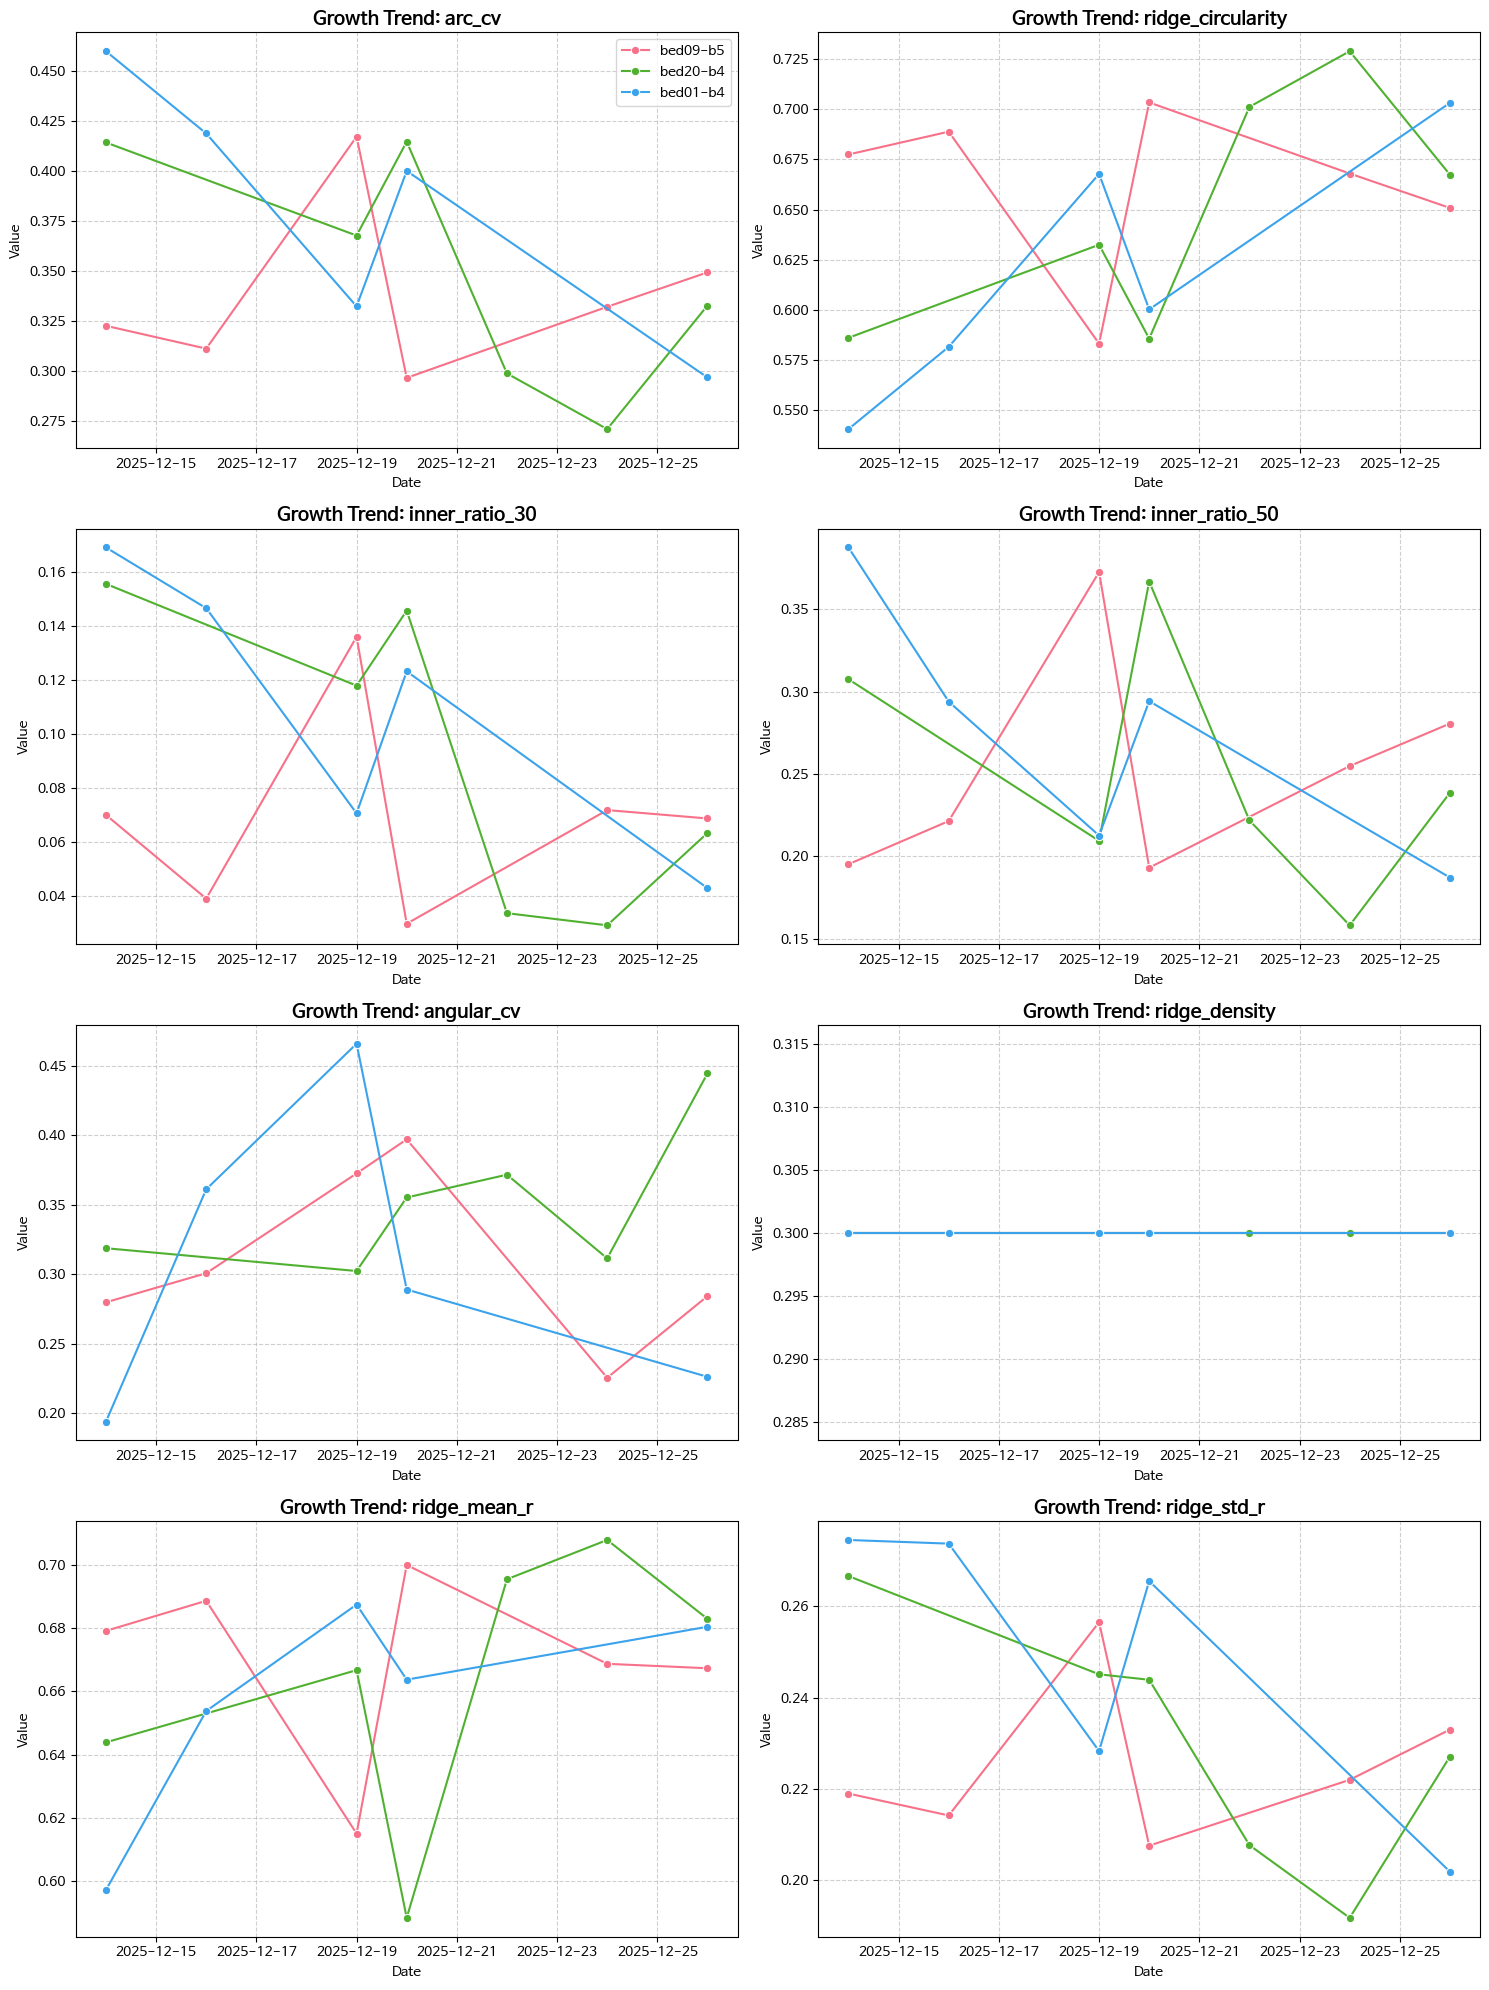

[15:40:24] 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/lettuce_growth_timeseries.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# 신규 지표 8개가 포함된 CSV 파일 경로
XLS_INPUT_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/ridge_metrics_results.csv"
SAVE_PLOT_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/viz_arc/lettuce_growth_timeseries.png'

# 시계열 분석 대상 개체 (베드-상추)
TARGET_PLANTS = [
    ('bed09', 'b5'),
    ('bed20', 'b4'),
    ('bed01', 'b4')
]

# 출력할 8대 지표 리스트
METRICS = [
    'arc_cv', 'ridge_circularity', 'inner_ratio_30', 'inner_ratio_50',
    'angular_cv', 'ridge_density', 'ridge_mean_r', 'ridge_std_r'
]

# ==========================================
# 2. 데이터 전처리 함수 (ID 분리 및 날짜 변환)
# ==========================================

def preprocess_timeseries_data(path):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 데이터 로드 중...")
    # Use pd.read_csv because the new metrics are in a CSV file
    df = pd.read_csv(path)

    # image_id 파싱: bed00_20251214_061656_cam2_b3_p01...
    # split('_') 결과: [0]bed00, [1]20251214, [2]061656, [3]cam2, [4]b3 ...
    def parse_info(img_id):
        parts = img_id.split('_')
        bed = parts[0]
        date_str = parts[1]
        lettuce = parts[4]
        dt = datetime.strptime(date_str, '%Y%m%d')
        return bed, lettuce, dt

    df[['bed', 'lettuce', 'date']] = df['image_id'].apply(lambda x: pd.Series(parse_info(x)))

    # 분석 대상만 필터링
    filtered_list = []
    for b, l in TARGET_PLANTS:
        tmp = df[(df['bed'] == b) & (df['lettuce'] == l)]
        filtered_list.append(tmp)

    final_df = pd.concat(filtered_list).sort_values('date')
    return final_df

# ==========================================
# 3. 시각화 실행 함수 (8개 Subplots)
# ==========================================

def plot_growth_curves(df):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 그래프 생성 중...")

    # 4행 2열 또는 2행 4열 구성 (8개 지표)
    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    axes = axes.flatten()

    # 개체별 색상 지정
    palette = sns.color_palette("husl", len(TARGET_PLANTS))
    labels = [f"{b}-{l}" for b, l in TARGET_PLANTS]

    for i, metric in enumerate(METRICS):
        ax = axes[i]

        for idx, (bed, let) in enumerate(TARGET_PLANTS):
            target_df = df[(df['bed'] == bed) & (df['lettuce'] == let)]

            # X축은 날짜, Y축은 지표 값
            sns.lineplot(
                data=target_df, x='date', y=metric,
                ax=ax, marker='o', label=f"{bed}-{let}", color=palette[idx]
            )

        ax.set_title(f'Growth Trend: {metric}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i != 0: ax.get_legend().remove() # 첫 번째 그래프에만 범례 표시

    plt.tight_layout()
    plt.savefig(SAVE_PLOT_PATH)
    plt.show()
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 저장 완료: {SAVE_PLOT_PATH}")

# ==========================================
# 실행부
# ==========================================
if __name__ == "__main__":
    if os.path.exists(XLS_INPUT_PATH):
        processed_df = preprocess_timeseries_data(XLS_INPUT_PATH)
        plot_growth_curves(processed_df)
    else:
        print(f"파일을 찾을 수 없습니다: {XLS_INPUT_PATH}")